In [3]:
pip install pandas matplotlib openpyxl notebook


   ------------- -------------------------- 2/6 [lark]
   ------------- -------------------------- 2/6 [lark]
   ------------- -------------------------- 2/6 [lark]
   ------------- -------------------------- 2/6 [lark]
   -------------------------- ------------- 4/6 [rfc3987-syntax]
   --------------------------------- ------ 5/6 [isoduration]
   ---------------------------------------- 6/6 [isoduration]

Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# This formatter will make y-axis show real numbers like $25,000,000
# instead of scientific notation like 2.5e7
money_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

print('Ready!')

Ready!


In [28]:
df = pd.read_excel('finance_transactions_dataset.xlsx')

In [29]:
print(df.shape)        # e.g. (1000, 14)
print(df.columns.tolist())

(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [30]:
df.head()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst
0,TXN1001,GreenEnergy,Energy,Marketing,Loan Repayment,NaN,104037.35,0.09,9363.36,94673.99,USD,2022-05-24,Pending,Analyst_B
1,TXN1002,LogiTrans,Logistics,IT,Loan Repayment,NaN,431438.64,0.10,43143.86,388294.78,USD,2023-08-04,Pending,Analyst_D
2,TXN1003,EduGroup,Education,Sales,Investment,NaN,494837.13,0.18,89070.68,405766.45,GBP,2023-08-05,Rejected,Analyst_B
3,TXN1004,HealthPlus,Healthcare,Sales,Revenue,NaN,59347.25,0.09,5341.25,54006.00,USD,2024-11-01,Pending,Analyst_A
4,TXN1005,EduGroup,Education,Finance,Loan Repayment,NaN,132500.40,0.15,19875.06,112625.34,GBP,2021-09-16,Approved,Analyst_C


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


In [32]:
df.describe().round(2)

,Amount,Tax_Rate,Tax_Amount,Net_Amount
count,961.00,1000.00,1000.00,960.00
mean,248309.09,0.18,44196.90,203859.56
std,145329.13,0.07,33447.57,120727.44
min,5132.61,0.05,355.38,3644.15
25%,115322.10,0.12,16896.31,94843.24
50%,250121.30,0.18,35780.50,200693.33
75%,375654.46,0.24,66364.00,308532.69
max,499771.64,0.30,148757.97,454365.87


In [33]:
df.isnull().sum()

Transaction_ID        0
Company              44
Sector                0
Department           54
Transaction_Type      0
Category            789
Amount               39
Tax_Rate              0
Tax_Amount            0
Net_Amount           40
Currency              0
Transaction_Date     48
Approval_Status      39
Analyst              45
dtype: int64

In [34]:
df.dropna(subset=['Amount', 'Net_Amount', 'Transaction_Date', 'Approval_Status'], inplace=True)

print('Rows remainig:', len(df))

Rows remainig: 845


In [35]:
df['Company']  = df['Company'].fillna('Unknown')
df['Department']  = df['Department'].fillna('Unknown')
df['Analyst']  = df['Analyst'].fillna('Unknown')
df['Category']  = df['Category'].fillna('N/A')

In [36]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df.dropna(subset=['Transaction_Date'], inplace=True)

df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)

print('Sample dates:')
print(df[['Transaction_Date', 'Year', 'Month']].head(3))

Sample dates:
  Transaction_Date  Year    Month
0       2022-05-24  2022  2022-05
1       2023-08-04  2023  2023-08
2       2023-08-05  2023  2023-08


In [37]:
df.drop_duplicates(inplace=True)
print('Final row count:', len(df))

Final row count: 845


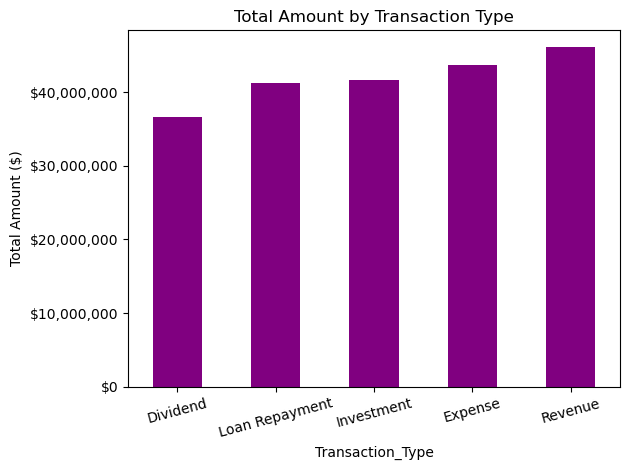

In [49]:
df.groupby('Transaction_Type')['Amount'].sum().sort_values().plot(kind='bar', 
color='purple')
plt.title('Total Amount by Transaction Type')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=15)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

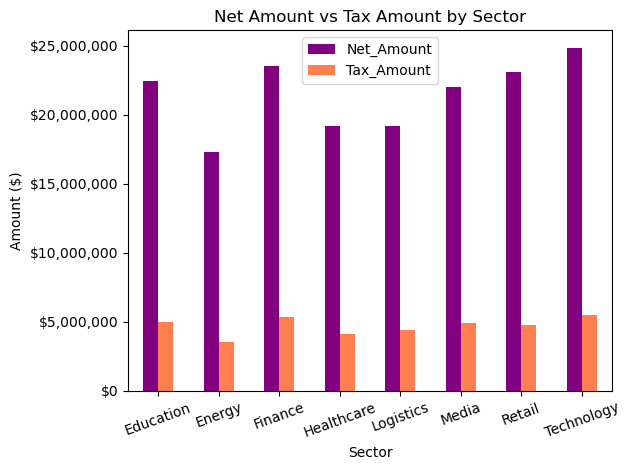

In [48]:
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar', color=['purple', 'coral'])
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt)   # show real numbers, not 
2.5e7
plt.tight_layout()
plt.show()

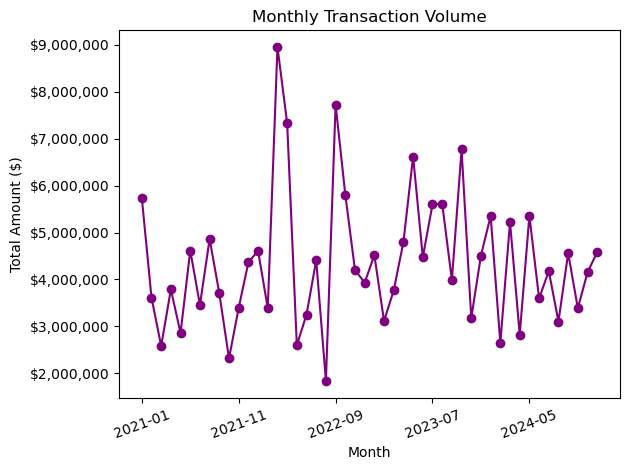

In [50]:
df.groupby('Month')['Amount'].sum().plot(kind='line', marker='o', color='purple')
plt.title('Monthly Transaction Volume')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt)   # show real numbers, not 
2.5e7
plt.tight_layout()
plt.show()

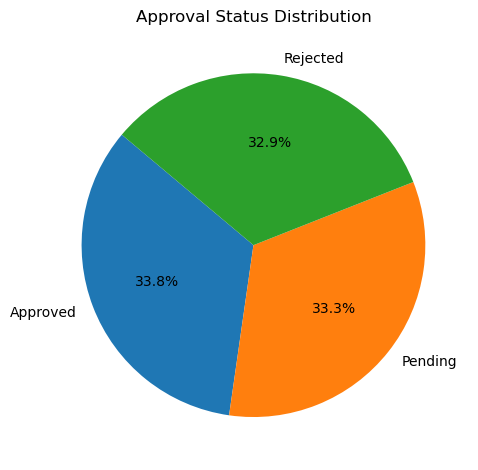

In [44]:
df['Approval_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
startangle=140)
plt.title('Approval Status Distribution')
plt.ylabel('')   # hides the default y-axis label on pie charts
plt.tight_layout()
plt.show()

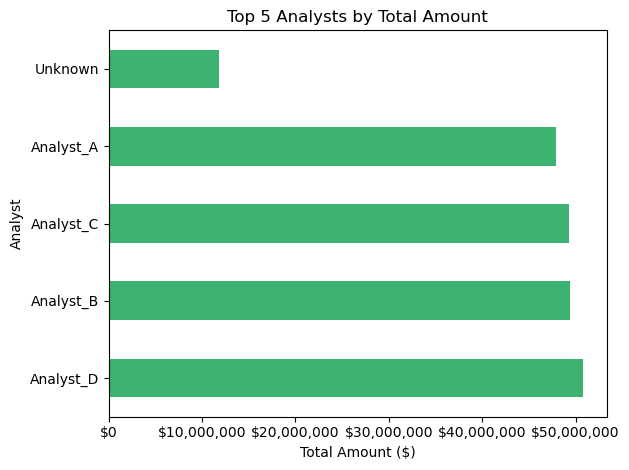

In [45]:
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh', 
color='mediumseagreen')
plt.title('Top 5 Analysts by Total Amount')
plt.xlabel('Total Amount ($)')
plt.gca().xaxis.set_major_formatter(money_fmt)   # x-axis for horizontal bars
plt.tight_layout()
plt.show()

In [52]:
print('=' * 46)
print('    FINANCE DATASET SUMMARY')
print('=' * 46)
print(f"Transactions: {len(df):,}")
print(f"Total Amount: ${df['Amount'].sum():,.0f}")
print(f"Total Tax Paid: ${df['Tax_Amount'].sum():,.0f}")
print(f"Total Net Amount: ${df['Net_Amount'].sum():,.0f}")
print(f"Avg Tax Rate:     {df['Tax_Rate'].mean()*100:,.1f}%")
print(f"Approval Rate:     {(df['Approval_Status']=='Approved').mean()*100:,.1f}%")
print(f"Top Sector:     {df.groupby('Sector')['Amount'].sum().idxmax()}")
print(f"Top Analyst:     {df.groupby('Analyst')['Amount'].sum().idxmax()}")
print('=' * 46)

    FINANCE DATASET SUMMARY
Transactions: 845
Total Amount: $209,284,457
Total Tax Paid: $37,622,745
Total Net Amount: $171,661,713
Avg Tax Rate:     17.9%
Approval Rate:     33.8%
Top Sector:     Technology
Top Analyst:     Analyst_D
